In [5]:
from pathlib import Path
from urllib.request import urlopen
import json
import platform
import random
import sys

!"{sys.executable}" -m pip install lime

import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.02)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 220, "axes.titleweight": "bold"})

ROOT = Path.cwd()
DATA_DIR = ROOT / "adult_income_data"
FIG_DIR = ROOT / "responsible_ai_outputs" / "figures"
ARTIFACT_DIR = ROOT / "responsible_ai_outputs" / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"scikit-learn {sklearn.__version__} | LIME 0.2.0.1 | {platform.platform()}")

Defaulting to user installation because normal site-packages is not writeable
scikit-learn 1.7.2 | LIME 0.2.0.1 | Windows-11-10.0.26200-SP0


In [6]:
COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
    "hours_per_week", "native_country", "income",
]
SOURCES = {
    "adult.data": "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    "adult.test": "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test",
}

def download_if_needed(filename, url):
    path = DATA_DIR / filename
    if not path.exists() or path.stat().st_size == 0:
        with urlopen(url, timeout=60) as response, open(path, "wb") as output:
            output.write(response.read())
    return path

train_path = download_if_needed("adult.data", SOURCES["adult.data"])
test_path = download_if_needed("adult.test", SOURCES["adult.test"])
raw_train = pd.read_csv(train_path, names=COLUMNS, na_values="?", skipinitialspace=True)
raw_test = pd.read_csv(test_path, names=COLUMNS, na_values="?", skipinitialspace=True, skiprows=1)
adult = pd.concat([raw_train, raw_test], ignore_index=True)
adult["income"] = adult["income"].astype(str).str.strip().str.rstrip(".").eq(">50K").astype(int)

clean_adult = adult.dropna().copy()
audit_data, _ = train_test_split(
    clean_adult, train_size=24000, stratify=clean_adult["income"], random_state=RANDOM_STATE
)
audit_data = audit_data.reset_index(drop=True)

dataset_summary = pd.DataFrame(
    {
        "Measure": ["Complete UCI Adult records", "Fixed audit sample", "Positive outcome rate", "Sensitive attributes audited", "Predictive features"],
        "Value": [
            f"{len(clean_adult):,}",
            f"{len(audit_data):,}",
            f"{audit_data['income'].mean():.1%}",
            "sex and race",
            "12 after excluding sensitive columns and sampling weight",
        ],
    }
)
display(dataset_summary)
display(audit_data[["age", "education", "occupation", "race", "sex", "hours_per_week", "income"]].head())

,Measure,Value
0,Complete UCI Adult records,"45,222"
1,Fixed audit sample,"24,000"
2,Positive outcome rate,24.8%
3,Sensitive attributes audited,sex and race
4,Predictive features,12 after excluding sensitive columns and sampl...


,age,education,occupation,race,sex,hours_per_week,income
0,40,Masters,Exec-managerial,White,Male,50,1
1,21,Some-college,Other-service,White,Female,40,0
2,25,Bachelors,Adm-clerical,Black,Female,40,0
3,40,HS-grad,Handlers-cleaners,White,Male,44,0
4,37,HS-grad,Craft-repair,White,Male,50,0


In [7]:
SENSITIVE_COLUMNS = ["sex", "race"]
DROP_FROM_MODEL = ["income", "sex", "race", "fnlwgt"]
X_raw = audit_data.drop(columns=DROP_FROM_MODEL)
y = audit_data["income"].astype(int)
sensitive = audit_data[SENSITIVE_COLUMNS].copy()

train_index, test_index = train_test_split(
    audit_data.index, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
X_train_raw, X_test_raw = X_raw.loc[train_index], X_raw.loc[test_index]
y_train, y_test = y.loc[train_index], y.loc[test_index]
sensitive_train, sensitive_test = sensitive.loc[train_index].copy(), sensitive.loc[test_index].copy()

numeric_features = X_train_raw.select_dtypes(include=np.number).columns.tolist()
categorical_features = [column for column in X_train_raw.columns if column not in numeric_features]
preprocessor = ColumnTransformer(
    [
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    verbose_feature_names_out=True,
)
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names_out()

split_summary = pd.DataFrame(
    {
        "Partition": ["Training", "Held-out test"],
        "Records": [len(y_train), len(y_test)],
        "Positive outcome rate": [f"{y_train.mean():.1%}", f"{y_test.mean():.1%}"],
    }
)
display(split_summary)
print(f"Encoded model features: {X_train.shape[1]} | audit-only attributes: {SENSITIVE_COLUMNS}")

,Partition,Records,Positive outcome rate
0,Training,18000,24.8%
1,Held-out test,6000,24.8%


Encoded model features: 96 | audit-only attributes: ['sex', 'race']


In [8]:
forest_template = RandomForestClassifier(
    n_estimators=280,
    max_depth=14,
    min_samples_leaf=8,
    max_features=0.65,
    n_jobs=1,
    random_state=RANDOM_STATE,
)
baseline_model = clone(forest_template)
baseline_model.fit(X_train, y_train)
baseline_probabilities = baseline_model.predict_proba(X_test)[:, 1]
baseline_predictions = (baseline_probabilities >= 0.50).astype(int)

def headline_metrics(y_true, probabilities, predictions):
    return {
        "accuracy": float(accuracy_score(y_true, predictions)),
        "precision": float(precision_score(y_true, predictions, zero_division=0)),
        "recall": float(recall_score(y_true, predictions, zero_division=0)),
        "f1": float(f1_score(y_true, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
    }

baseline_headline = headline_metrics(y_test, baseline_probabilities, baseline_predictions)
headline_table = pd.DataFrame(
    {"Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"], "Held-out score": list(baseline_headline.values())}
)
headline_table["Held-out score"] = headline_table["Held-out score"].map("{:.4f}".format)
display(headline_table)

,Metric,Held-out score
0,Accuracy,0.8558
1,Precision,0.7723
2,Recall,0.5931
3,F1,0.6710
4,ROC-AUC,0.9095


,feature,importance
30,categorical__marital_status_Married-civ-spouse,0.2607
2,numeric__capital_gain,0.1911
1,numeric__education_num,0.1725
0,numeric__age,0.0795
49,categorical__relationship_Husband,0.0761
3,numeric__capital_loss,0.0543
4,numeric__hours_per_week,0.0441
38,categorical__occupation_Exec-managerial,0.0246
54,categorical__relationship_Wife,0.0110
44,categorical__occupation_Prof-specialty,0.0102


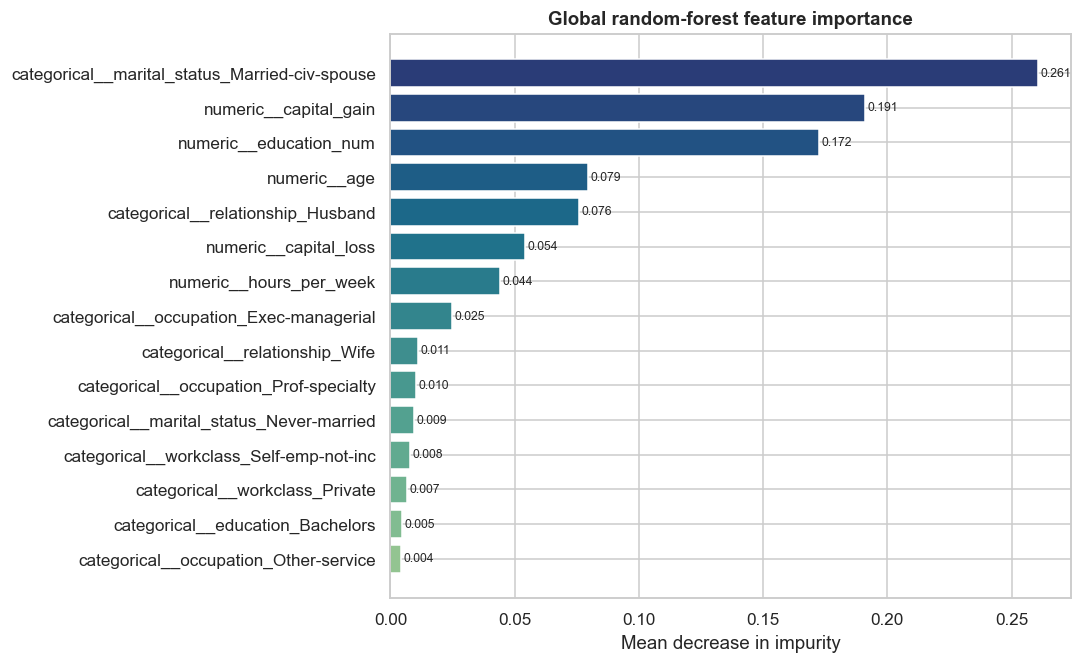

In [9]:
importance = pd.DataFrame(
    {"feature": feature_names, "importance": baseline_model.feature_importances_}
).sort_values("importance", ascending=False)
top_importance = importance.head(15).sort_values("importance")
display(importance.head(15).style.format({"importance": "{:.4f}"}))

fig, ax = plt.subplots(figsize=(10, 6.2))
bars = ax.barh(top_importance["feature"], top_importance["importance"], color=sns.color_palette("crest", len(top_importance)))
ax.set(title="Global random-forest feature importance", xlabel="Mean decrease in impurity", ylabel="")
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f"{bar.get_width():.3f}", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_global_feature_importance.png", bbox_inches="tight")
plt.show()
importance.head(30).to_csv(ARTIFACT_DIR / "global_feature_importance.csv", index=False)

,Actual outcome,Predicted probability (>50K),Predicted class,Audit-only sex,Audit-only race
0,>50K,100.0%,>50K,Male,White


,age,workclass,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country
1335,43,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,7298,0,40,United-States


,local condition,contribution toward >50K
0,capital_gain > 0.00,+0.6769
1,marital_status=Married-civ-spouse,+0.1729
2,capital_loss <= 0.00,-0.1021
3,occupation=Exec-managerial,+0.0802
4,10.00 < education_num <= 13.00,+0.0752
5,hours_per_week <= 40.00,-0.0661
6,37.00 < age <= 47.00,+0.0493
7,relationship=Husband,+0.0255
8,education=Bachelors,+0.0088
9,native_country=United-States,-0.0043


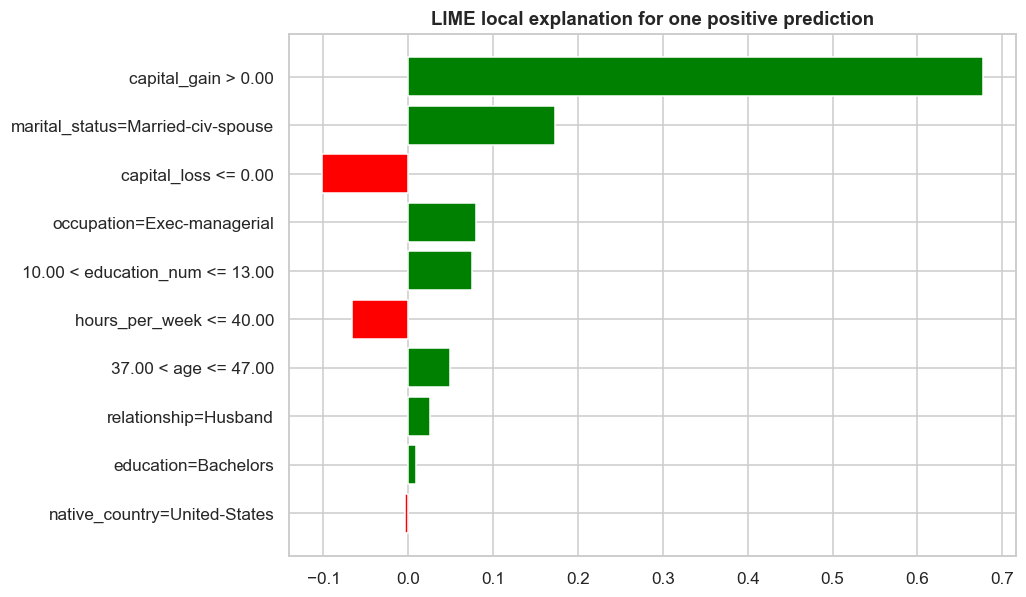

In [10]:
from sklearn.preprocessing import OrdinalEncoder

local_candidates = np.flatnonzero((y_test.to_numpy() == 1) & (baseline_predictions == 1))
local_position = int(local_candidates[0])
local_record = X_test_raw.iloc[[local_position]]
local_sensitive = sensitive_test.iloc[local_position]

lime_feature_order = numeric_features + categorical_features
category_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
lime_train_categorical = category_encoder.fit_transform(X_train_raw[categorical_features])
lime_train_matrix = np.column_stack([
    X_train_raw[numeric_features].to_numpy(dtype=float),
    lime_train_categorical,
])
lime_categorical_positions = list(range(len(numeric_features), len(lime_feature_order)))
lime_category_names = {
    len(numeric_features) + index: categories.tolist()
    for index, categories in enumerate(category_encoder.categories_)
}

def lime_predict_proba(lime_matrix):
    frame = pd.DataFrame(lime_matrix, columns=lime_feature_order)
    for column in numeric_features:
        frame[column] = frame[column].astype(float)
    for index, column in enumerate(categorical_features):
        codes = np.rint(frame[column].to_numpy()).astype(int)
        codes = np.clip(codes, 0, len(category_encoder.categories_[index]) - 1)
        frame[column] = category_encoder.categories_[index][codes]
    transformed = preprocessor.transform(frame[X_train_raw.columns])
    return baseline_model.predict_proba(transformed)

local_lime_row = lime_train_matrix[0].copy()
raw_row = X_test_raw.iloc[local_position]
local_lime_row[:len(numeric_features)] = raw_row[numeric_features].to_numpy(dtype=float)
local_lime_row[len(numeric_features):] = category_encoder.transform(
    raw_row[categorical_features].to_frame().T
)[0]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=lime_train_matrix,
    feature_names=lime_feature_order,
    class_names=["<=50K", ">50K"],
    categorical_features=lime_categorical_positions,
    categorical_names=lime_category_names,
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)
lime_explanation = explainer.explain_instance(
    local_lime_row,
    lime_predict_proba,
    labels=(1,),
    num_features=10,
    num_samples=3000,
)
local_prediction = pd.DataFrame(
    {
        "Actual outcome": [">50K" if y_test.iloc[local_position] else "<=50K"],
        "Predicted probability (>50K)": [baseline_probabilities[local_position]],
        "Predicted class": [">50K" if baseline_predictions[local_position] else "<=50K"],
        "Audit-only sex": [local_sensitive["sex"]],
        "Audit-only race": [local_sensitive["race"]],
    }
)
display(local_prediction.style.format({"Predicted probability (>50K)": "{:.1%}"}))
display(local_record)

lime_rows = pd.DataFrame(lime_explanation.as_list(label=1), columns=["local condition", "contribution toward >50K"])
display(lime_rows.style.format({"contribution toward >50K": "{:+.4f}"}))
lime_rows.to_csv(ARTIFACT_DIR / "lime_local_explanation.csv", index=False)

lime_figure = lime_explanation.as_pyplot_figure(label=1)
lime_figure.set_size_inches(9.5, 5.6)
plt.title("LIME local explanation for one positive prediction")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_lime_local_explanation.png", bbox_inches="tight")
plt.show()
lime_explanation.save_to_file(str(ARTIFACT_DIR / "lime_local_explanation.html"))

In [11]:
def make_race_group(series):
    retained = {"White", "Black", "Asian-Pac-Islander"}
    return series.where(series.isin(retained), "Other / smaller groups")

def group_metric_table(y_true, y_pred, groups, group_name):
    frame = pd.DataFrame({"y_true": np.asarray(y_true), "y_pred": np.asarray(y_pred), "group": np.asarray(groups)})
    rows = []
    for group, subset in frame.groupby("group", observed=True):
        tn, fp, fn, tp = confusion_matrix(subset["y_true"], subset["y_pred"], labels=[0, 1]).ravel()
        rows.append(
            {
                group_name: group,
                "records": len(subset),
                "selection_rate": subset["y_pred"].mean(),
                "accuracy": (subset["y_pred"] == subset["y_true"]).mean(),
                "true_positive_rate": tp / (tp + fn) if (tp + fn) else np.nan,
                "false_positive_rate": fp / (fp + tn) if (fp + tn) else np.nan,
                "observed_positive_rate": subset["y_true"].mean(),
            }
        )
    return pd.DataFrame(rows).sort_values(group_name).reset_index(drop=True)

def disparity_summary(metrics, group_name):
    selection = metrics["selection_rate"]
    tpr = metrics["true_positive_rate"]
    return {
        "group_attribute": group_name,
        "demographic_parity_difference": float(selection.max() - selection.min()),
        "disparate_impact_ratio": float(selection.min() / selection.max()) if selection.max() else np.nan,
        "equal_opportunity_difference": float(tpr.max() - tpr.min()),
    }

sex_metrics_baseline = group_metric_table(y_test, baseline_predictions, sensitive_test["sex"], "sex")
race_groups_test = make_race_group(sensitive_test["race"])
race_metrics_baseline = group_metric_table(y_test, baseline_predictions, race_groups_test, "race_group")
sex_gap_baseline = disparity_summary(sex_metrics_baseline, "sex")
race_gap_baseline = disparity_summary(race_metrics_baseline, "race_group")

display(sex_metrics_baseline.style.format({
    "selection_rate": "{:.1%}", "accuracy": "{:.1%}", "true_positive_rate": "{:.1%}",
    "false_positive_rate": "{:.1%}", "observed_positive_rate": "{:.1%}",
}))
display(race_metrics_baseline.style.format({
    "selection_rate": "{:.1%}", "accuracy": "{:.1%}", "true_positive_rate": "{:.1%}",
    "false_positive_rate": "{:.1%}", "observed_positive_rate": "{:.1%}",
}))
display(pd.DataFrame([sex_gap_baseline, race_gap_baseline]).style.format({
    "demographic_parity_difference": "{:.1%}",
    "disparate_impact_ratio": "{:.3f}",
    "equal_opportunity_difference": "{:.1%}",
}))

,sex,records,selection_rate,accuracy,true_positive_rate,false_positive_rate,observed_positive_rate
0,Female,1983,8.1%,92.4%,52.5%,2.5%,11.2%
1,Male,4017,24.4%,82.2%,60.5%,7.8%,31.5%


,race_group,records,selection_rate,accuracy,true_positive_rate,false_positive_rate,observed_positive_rate
0,Asian-Pac-Islander,175,28.0%,78.3%,59.3%,12.1%,33.7%
1,Black,582,8.1%,90.4%,44.6%,2.0%,14.3%
2,Other / smaller groups,94,8.5%,89.4%,42.9%,2.5%,14.9%
3,White,5149,20.2%,85.2%,60.4%,6.1%,25.8%


,group_attribute,demographic_parity_difference,disparate_impact_ratio,equal_opportunity_difference
0,sex,16.3%,0.332,8.1%
1,race_group,19.9%,0.288,17.5%


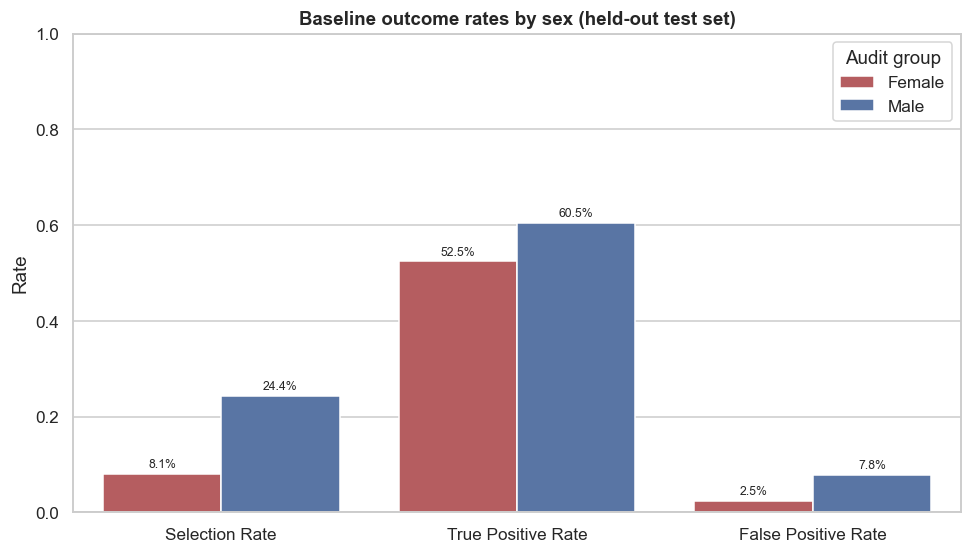

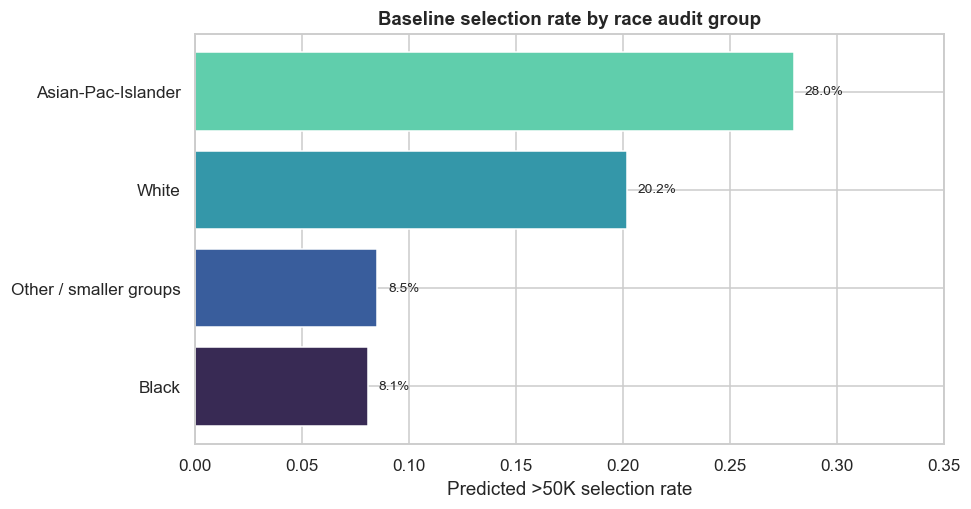

In [12]:
rate_plot = sex_metrics_baseline.melt(
    id_vars="sex",
    value_vars=["selection_rate", "true_positive_rate", "false_positive_rate"],
    var_name="metric",
    value_name="rate",
)
rate_plot["metric"] = rate_plot["metric"].str.replace("_", " ").str.title()
fig, ax = plt.subplots(figsize=(9, 5.2))
sns.barplot(data=rate_plot, x="metric", y="rate", hue="sex", palette=["#C44E52", "#4C72B0"], ax=ax)
ax.set(title="Baseline outcome rates by sex (held-out test set)", xlabel="", ylabel="Rate", ylim=(0, 1))
ax.legend(title="Audit group")
for container in ax.containers:
    ax.bar_label(container, labels=[f"{100 * value:.1f}%" for value in container.datavalues], padding=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_sex_fairness_rates.png", bbox_inches="tight")
plt.show()

race_plot = race_metrics_baseline.sort_values("selection_rate")
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(race_plot["race_group"], race_plot["selection_rate"], color=sns.color_palette("mako", len(race_plot)))
ax.set(title="Baseline selection rate by race audit group", xlabel="Predicted >50K selection rate", ylabel="")
ax.set_xlim(0, max(0.35, race_plot["selection_rate"].max() + 0.05))
for bar in bars:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f"{bar.get_width():.1%}", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_race_selection_rates.png", bbox_inches="tight")
plt.show()

,model,accuracy,f1,roc_auc,sex_selection_rate_gap,sex_disparate_impact_ratio,sex_tpr_gap
0,Baseline forest,0.8558,0.6710,0.9095,16.3%,0.332,8.1%
1,Sex/outcome reweighted forest,0.8253,0.6969,0.9067,24.4%,0.403,4.6%


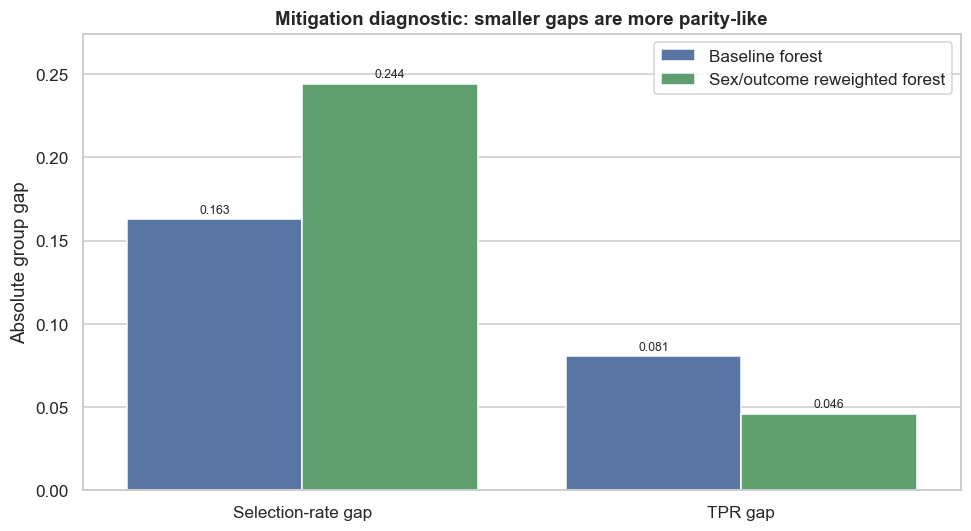

In [13]:
sex_outcome_cell = sensitive_train["sex"].astype(str) + " | outcome=" + y_train.astype(str)
cell_counts = sex_outcome_cell.value_counts()
sample_weights = sex_outcome_cell.map(lambda value: 1.0 / cell_counts[value]).to_numpy()
sample_weights = sample_weights / sample_weights.mean()

reweighted_model = clone(forest_template)
reweighted_model.fit(X_train, y_train, sample_weight=sample_weights)
reweighted_probabilities = reweighted_model.predict_proba(X_test)[:, 1]
reweighted_predictions = (reweighted_probabilities >= 0.50).astype(int)
reweighted_headline = headline_metrics(y_test, reweighted_probabilities, reweighted_predictions)
sex_metrics_reweighted = group_metric_table(y_test, reweighted_predictions, sensitive_test["sex"], "sex")
sex_gap_reweighted = disparity_summary(sex_metrics_reweighted, "sex")

comparison = pd.DataFrame(
    [
        {
            "model": "Baseline forest",
            "accuracy": baseline_headline["accuracy"],
            "f1": baseline_headline["f1"],
            "roc_auc": baseline_headline["roc_auc"],
            "sex_selection_rate_gap": sex_gap_baseline["demographic_parity_difference"],
            "sex_disparate_impact_ratio": sex_gap_baseline["disparate_impact_ratio"],
            "sex_tpr_gap": sex_gap_baseline["equal_opportunity_difference"],
        },
        {
            "model": "Sex/outcome reweighted forest",
            "accuracy": reweighted_headline["accuracy"],
            "f1": reweighted_headline["f1"],
            "roc_auc": reweighted_headline["roc_auc"],
            "sex_selection_rate_gap": sex_gap_reweighted["demographic_parity_difference"],
            "sex_disparate_impact_ratio": sex_gap_reweighted["disparate_impact_ratio"],
            "sex_tpr_gap": sex_gap_reweighted["equal_opportunity_difference"],
        },
    ]
)
display(comparison.style.format({
    "accuracy": "{:.4f}", "f1": "{:.4f}", "roc_auc": "{:.4f}",
    "sex_selection_rate_gap": "{:.1%}", "sex_disparate_impact_ratio": "{:.3f}", "sex_tpr_gap": "{:.1%}",
}))

comparison.to_csv(ARTIFACT_DIR / "mitigation_comparison.csv", index=False)
sex_metrics_baseline.to_csv(ARTIFACT_DIR / "baseline_sex_group_metrics.csv", index=False)
race_metrics_baseline.to_csv(ARTIFACT_DIR / "baseline_race_group_metrics.csv", index=False)

compare_plot = comparison.melt(
    id_vars="model", value_vars=["sex_selection_rate_gap", "sex_tpr_gap"],
    var_name="fairness measure", value_name="gap",
)
compare_plot["fairness measure"] = compare_plot["fairness measure"].map({
    "sex_selection_rate_gap": "Selection-rate gap",
    "sex_tpr_gap": "TPR gap",
})
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=compare_plot, x="fairness measure", y="gap", hue="model", palette=["#4C72B0", "#55A868"], ax=ax)
ax.set(title="Mitigation diagnostic: smaller gaps are more parity-like", xlabel="", ylabel="Absolute group gap")
ax.set_ylim(0, max(0.05, compare_plot["gap"].max() + 0.03))
ax.legend(title="")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_mitigation_comparison.png", bbox_inches="tight")
plt.show()


In [14]:
audit_payload = {
    "dataset": {
        "name": "UCI Adult Income",
        "audit_records": int(len(audit_data)),
        "train_records": int(len(y_train)),
        "test_records": int(len(y_test)),
        "sensitive_attributes_audited": SENSITIVE_COLUMNS,
        "sensitive_attributes_excluded_from_model": True,
    },
    "baseline_headline_metrics": {key: round(value, 6) for key, value in baseline_headline.items()},
    "reweighted_headline_metrics": {key: round(value, 6) for key, value in reweighted_headline.items()},
    "baseline_sex_disparity": {key: (round(value, 6) if isinstance(value, float) else value) for key, value in sex_gap_baseline.items()},
    "reweighted_sex_disparity": {key: (round(value, 6) if isinstance(value, float) else value) for key, value in sex_gap_reweighted.items()},
    "baseline_race_disparity": {key: (round(value, 6) if isinstance(value, float) else value) for key, value in race_gap_baseline.items()},
    "local_explanation_position": local_position,
    "library_versions": {"scikit_learn": sklearn.__version__, "lime": "0.2.0.1"},
}
with open(ARTIFACT_DIR / "audit_metrics.json", "w", encoding="utf-8") as output:
    json.dump(audit_payload, output, indent=2)
print("Responsible AI audit complete.")
print(f"Baseline test ROC-AUC: {baseline_headline['roc_auc']:.4f}")
print(f"Baseline sex selection-rate gap: {sex_gap_baseline['demographic_parity_difference']:.1%}")
print(f"Reweighted sex selection-rate gap: {sex_gap_reweighted['demographic_parity_difference']:.1%}")

Responsible AI audit complete.
Baseline test ROC-AUC: 0.9095
Baseline sex selection-rate gap: 16.3%
Reweighted sex selection-rate gap: 24.4%
